# Synthetic benchmark metrics analysis

This jupyter notebook analyzes the profiler metrics collected from the synthetic benchmark data. The goal is to understand the performance characteristics of the system under test and identify any potential bottlenecks or areas for optimization.

In [72]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# import helper scripts from local directory
from helpers.visualization import save_or_show, format_elapsed_axis, color_for
from helpers.dataset import _get_components, _get_ecall_names

## Configuration

In [73]:
METRICS_CSV_DIR = Path("data/medium/single-worker/sws01/profiler")
OUTPUT_DIR = METRICS_CSV_DIR / "plots"
SAVE_PLOTS = False
PLOT_FORMAT = "png"

if not METRICS_CSV_DIR.is_dir():
    raise FileNotFoundError(f"Source directory does not exist: '{METRICS_CSV_DIR}'")

if SAVE_PLOTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Loading CSVs

In [74]:
def load_profiler_csvs(csv_dir: Path) -> pd.DataFrame:
    """Load and concatenate all profiler-*.csv files from the given directory."""
    files = sorted(csv_dir.glob("profiler-*.csv"))
    if not files:
        print(f"ERROR: No profiler-*.csv files found in '{csv_dir}'.")
        sys.exit(1)

    frames = []
    for f in files:
        try:
            df = pd.read_csv(f)
            df["source_file"] = f.name
            frames.append(df)
        except Exception as e:
            print(f"  WARNING: Failed to read {f.name}: {e}")

    if not frames:
        print("ERROR: No valid CSV data loaded.")
        sys.exit(1)

    # combine all dataframes into one
    combined = pd.concat(frames, ignore_index=True)
    combined["timestamp"] = pd.to_datetime(combined["timestamp"])

    # Compute a relative time in seconds from the earliest timestamp
    t0 = combined["timestamp"].min()
    combined["elapsed_s"] = (combined["timestamp"] - t0).dt.total_seconds()

    # Build a label for each task
    combined["task_label"] = combined["component"] + " (task " + combined["taskId"].astype(str) + ")"
    return combined

### Dataset overview

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24628 entries, 0 to 24627
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   timestamp    24628 non-null  datetime64[ns, UTC]
 1   component    24628 non-null  object             
 2   taskId       24628 non-null  int64              
 3   type         24628 non-null  object             
 4   name         24628 non-null  object             
 5   total        24628 non-null  int64              
 6   sampled      8720 non-null   float64            
 7   avgMs        8720 non-null   float64            
 8   minMs        8720 non-null   float64            
 9   maxMs        8720 non-null   float64            
 10  source_file  24628 non-null  object             
 11  elapsed_s    24628 non-null  float64            
 12  task_label   24628 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(5), int64(2), object(5)
memory usage: 2.4

In [76]:
df.head()

,timestamp,component,taskId,type,name,total,sampled,avgMs,minMs,maxMs,source_file,elapsed_s,task_label
0,2026-03-10 10:49:27.295378233+00:00,bolt-data-perturbation,2,ecall,addContribution,58444,2917.0,0.190,0.154,17.313,profiler-bolt-data-perturbation-task2.csv,81.814458,bolt-data-perturbation (task 2)
1,2026-03-10 10:49:27.295378233+00:00,bolt-data-perturbation,2,ecall,getEncryptedSnapshot,4,4.0,17737.364,1275.438,43593.080,profiler-bolt-data-perturbation-task2.csv,81.814458,bolt-data-perturbation (task 2)
2,2026-03-10 10:49:27.295378233+00:00,bolt-data-perturbation,2,ecall,snapshot_lock_wait,0,4.0,0.322,0.001,0.602,profiler-bolt-data-perturbation-task2.csv,81.814458,bolt-data-perturbation (task 2)
3,2026-03-10 10:49:27.295378233+00:00,bolt-data-perturbation,2,ecall,getEncryptedDummyPartial,2,2.0,0.648,0.611,0.685,profiler-bolt-data-perturbation-task2.csv,81.814458,bolt-data-perturbation (task 2)
4,2026-03-10 10:49:27.295378233+00:00,bolt-data-perturbation,2,counter,real_emissions,4,NaN,NaN,NaN,NaN,profiler-bolt-data-perturbation-task2.csv,81.814458,bolt-data-perturbation (task 2)


In [77]:
print(f"Loading profiler CSVs from: {METRICS_CSV_DIR}")
df = load_profiler_csvs(METRICS_CSV_DIR)
print(f"  Loaded {len(df)} rows from {df['source_file'].nunique()} file(s)")
print(f"  Components: {', '.join(_get_components(df))}")
print(f"  Time span: {df['elapsed_s'].max():.1f}s ({df['elapsed_s'].max()/60:.1f} minutes)")
print(f"  Output: {OUTPUT_DIR}/")
print()

Loading profiler CSVs from: data/medium/single-worker/sws01/profiler
  Loaded 24628 rows from 9 file(s)
  Components: bolt-data-perturbation, bolt-histogram-aggregation, bolt-user-contribution-bounding
  Time span: 14706.3s (245.1 minutes)
  Output: data/medium/single-worker/sws01/profiler/plots/



## Plot 1: ECALL Latency Over Time

Shows average latency over time for each ECALL, with an overview comparing all tasks and per-task detail plots.

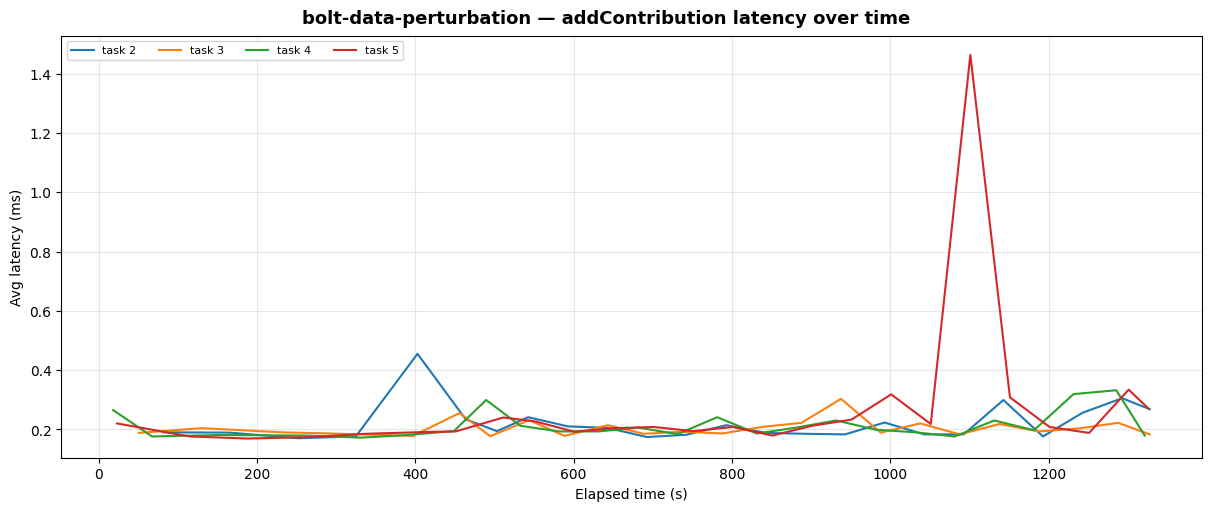

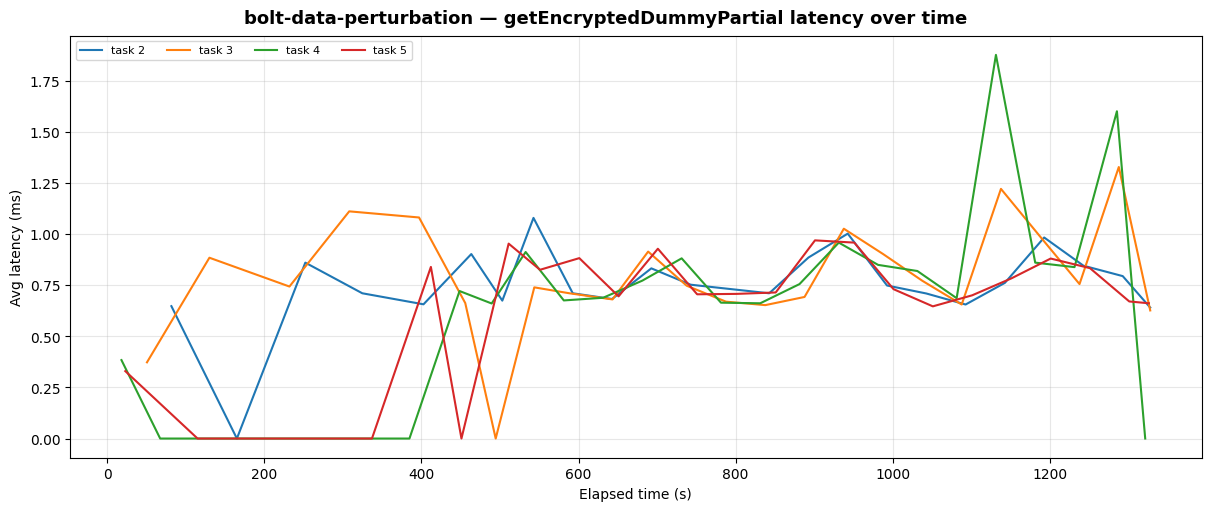

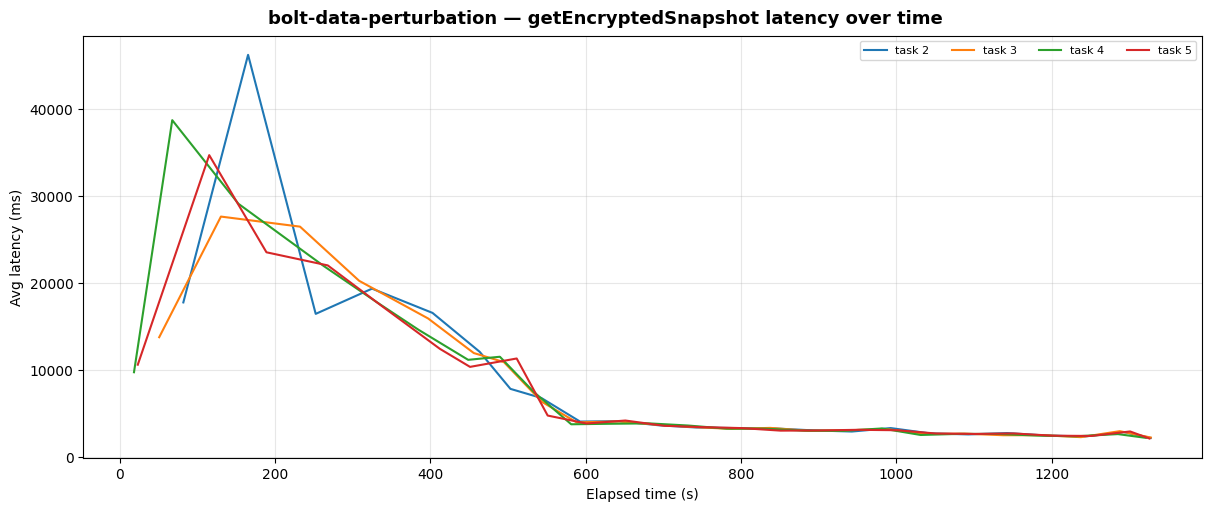

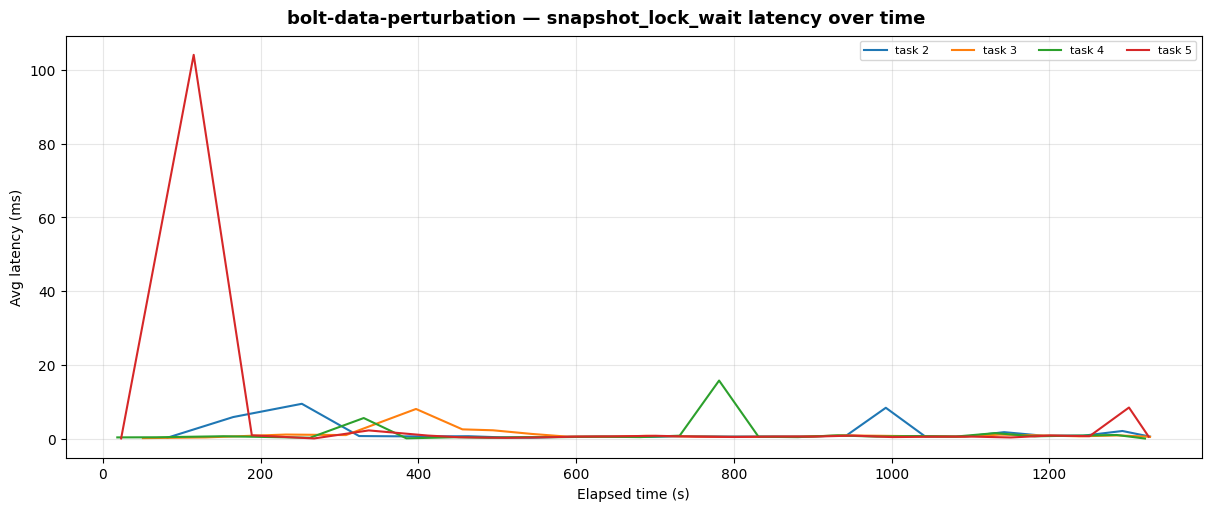

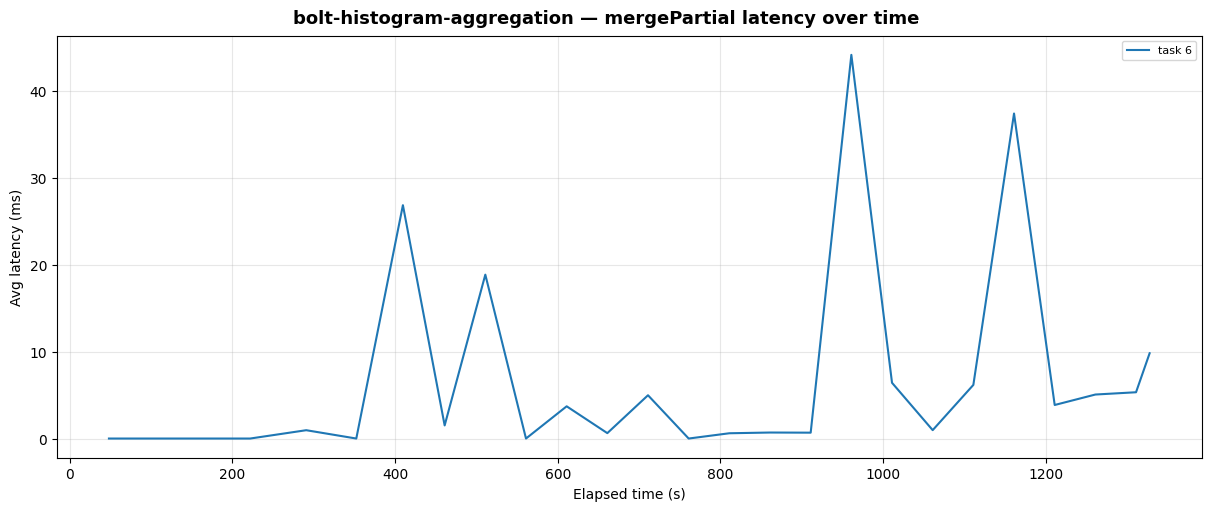

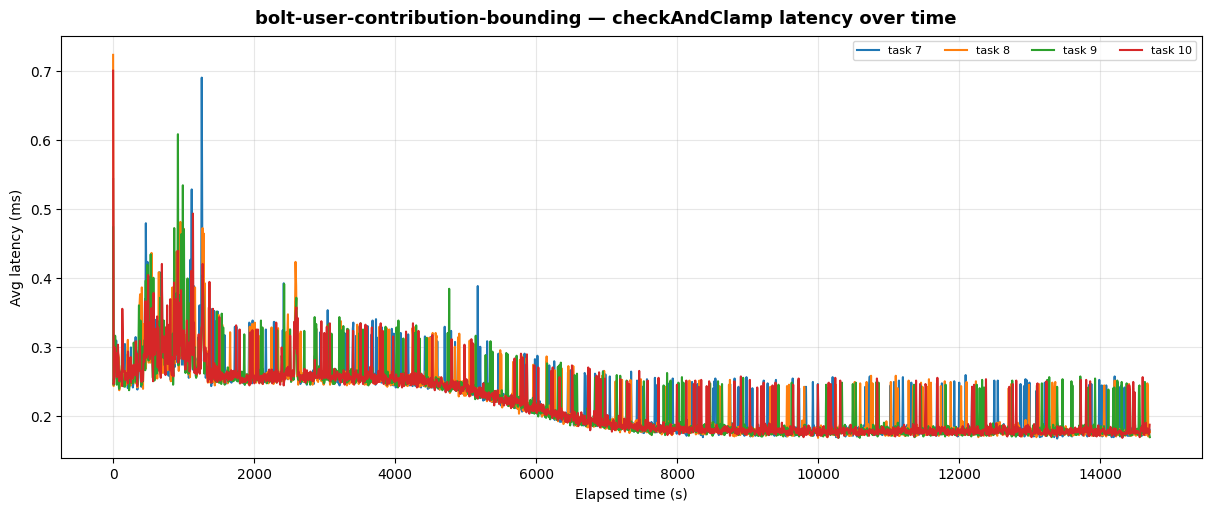

In [78]:
ecalls = df[df["type"] == "ecall"]
if not ecalls.empty:
    components = _get_components(ecalls)

    for comp in components:
        comp_data = ecalls[ecalls["component"] == comp]
        ecall_names = _get_ecall_names(ecalls, comp)

        for ecall_name in ecall_names:
            ed = comp_data[comp_data["name"] == ecall_name]
            tasks = sorted(ed["taskId"].unique())
            n_tasks = len(tasks)

            fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
            for i, task in enumerate(tasks):
                td = ed[ed["taskId"] == task].sort_values("elapsed_s")
                ax.plot(td["elapsed_s"], td["avgMs"],
                        label=f"task {task}", color=color_for(i), linewidth=1.5)
            ax.set_ylabel("Avg latency (ms)")
            ax.legend(fontsize=8, ncol=min(n_tasks, 6))
            ax.grid(True, alpha=0.3)
            format_elapsed_axis(ax)
            fig.suptitle(f"{comp} — {ecall_name} latency over time", fontsize=13, fontweight="bold")
            save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"latency-{comp}-{ecall_name}", PLOT_FORMAT, True)

## Plot 2: ECALL Latency Distribution (Box Plots)

Distribution of average latency per ECALL within each component.

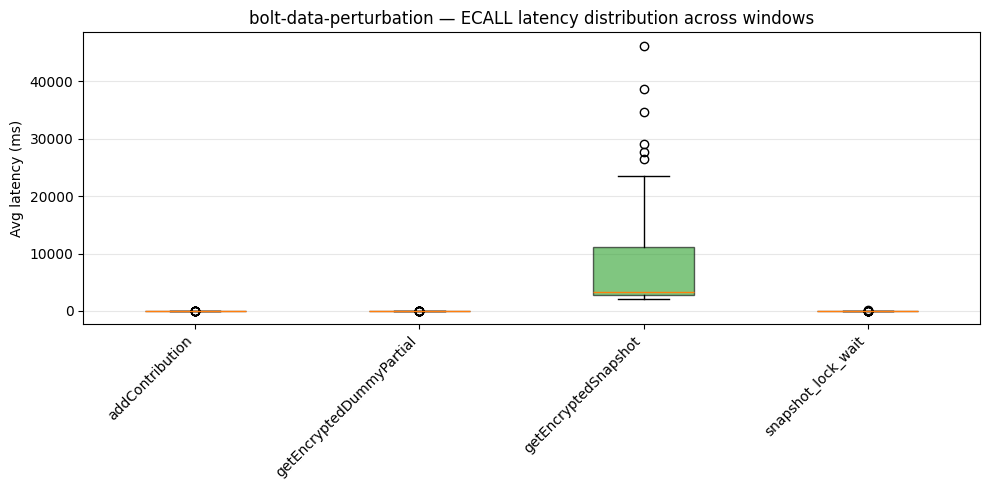

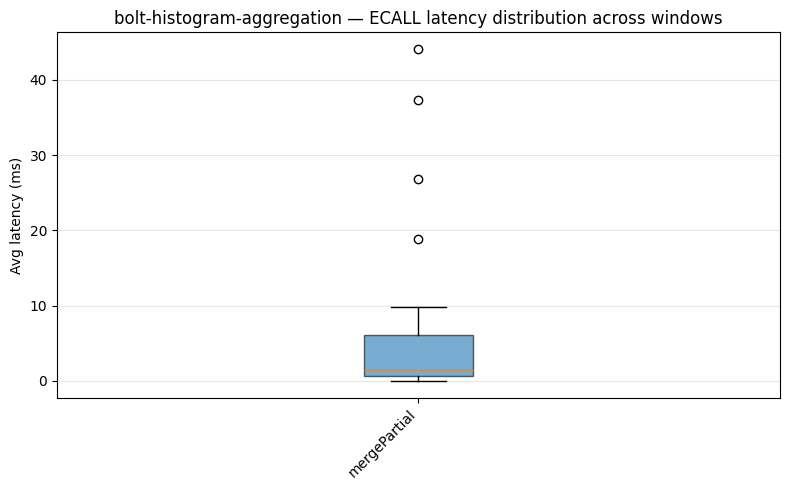

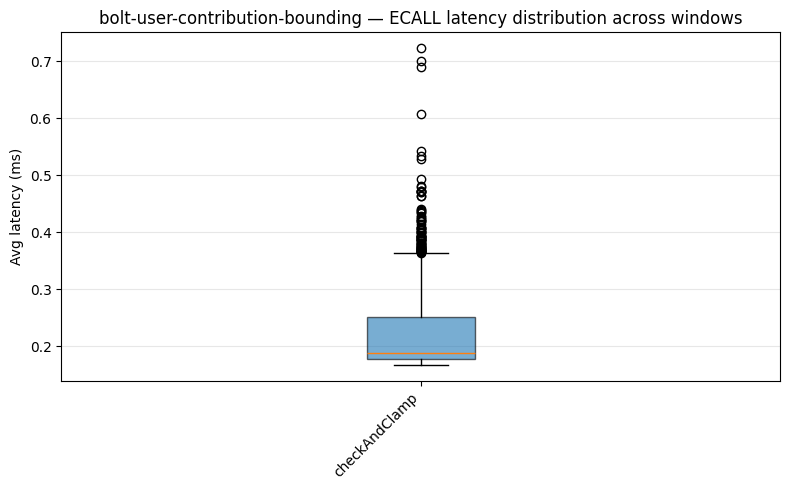

In [79]:
ecalls = df[df["type"] == "ecall"]
if not ecalls.empty:
    components = _get_components(ecalls)

    for comp in components:
        comp_data = ecalls[ecalls["component"] == comp]
        ecall_names = _get_ecall_names(ecalls, comp)

        data_for_box = []
        labels = []
        for en in ecall_names:
            vals = comp_data.loc[comp_data["name"] == en, "avgMs"].dropna()
            if not vals.empty:
                data_for_box.append(vals.values)
                labels.append(en)

        if not data_for_box:
            continue

        fig, ax = plt.subplots(figsize=(max(8, len(labels) * 2.5), 5))
        bp = ax.boxplot(data_for_box, labels=labels, patch_artist=True)
        for i, patch in enumerate(bp["boxes"]):
            patch.set_facecolor(color_for(i))
            patch.set_alpha(0.6)
        ax.set_ylabel("Avg latency (ms)")
        ax.set_title(f"{comp} — ECALL latency distribution across windows")
        ax.grid(True, axis="y", alpha=0.3)
        plt.xticks(rotation=45, ha="right")
        save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"boxplot-{comp}", PLOT_FORMAT, True)

## Plot 3: Throughput Over Time

Total invocations per measurement window, summed across all tasks.

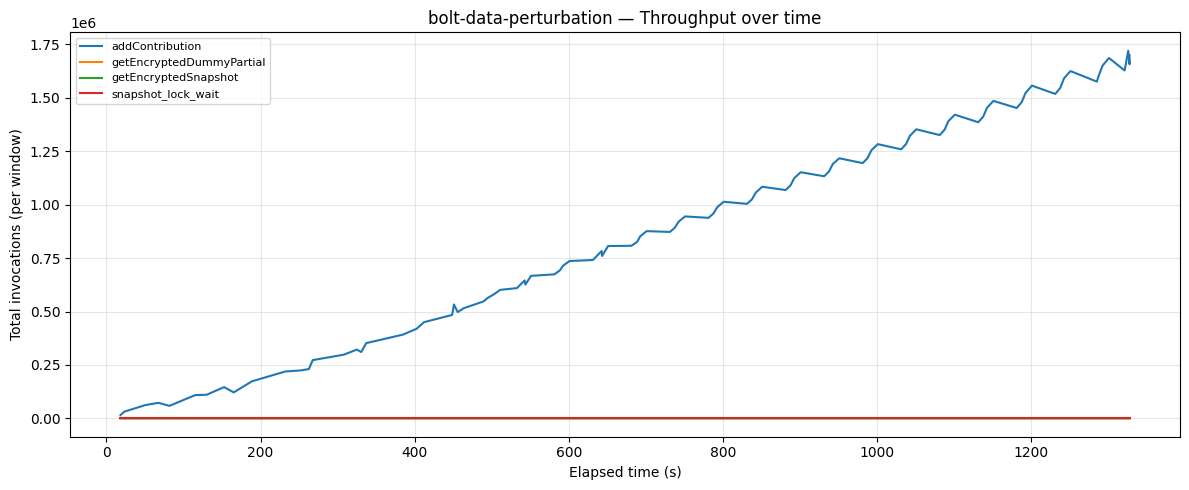

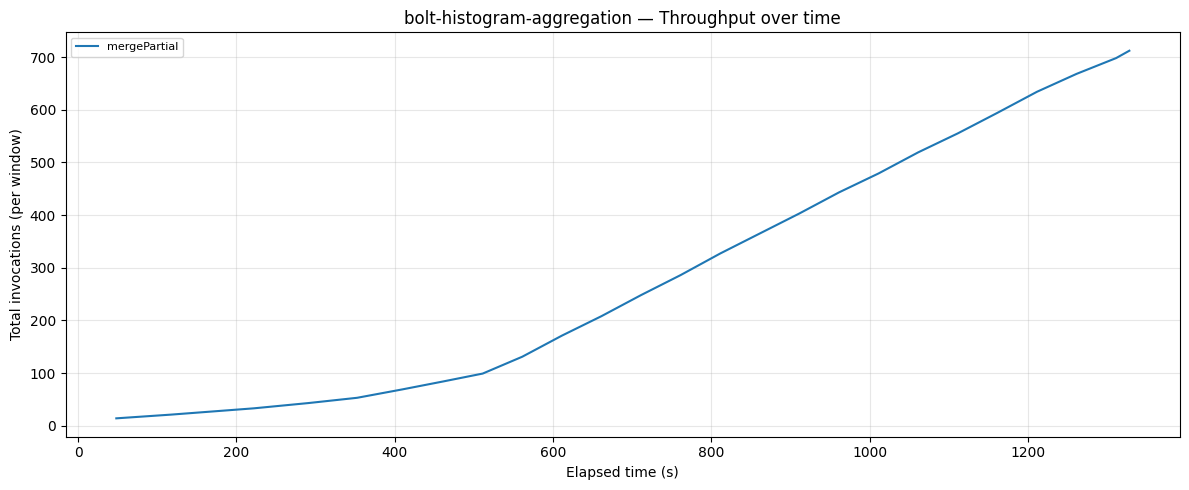

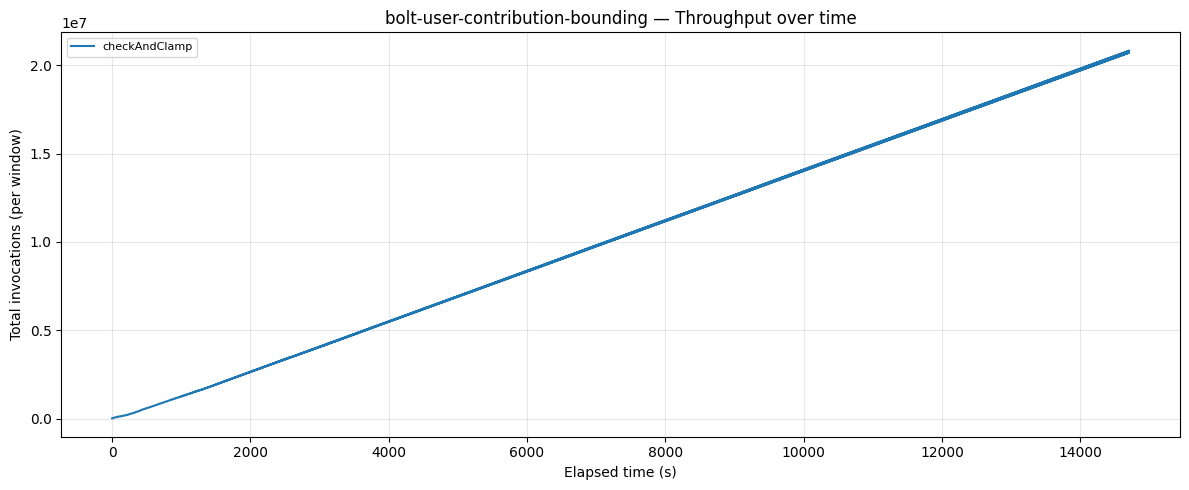

In [80]:
ecalls = df[df["type"] == "ecall"]
if not ecalls.empty:
    components = _get_components(ecalls)

    for comp in components:
        comp_data = ecalls[ecalls["component"] == comp]
        ecall_names = _get_ecall_names(ecalls, comp)

        fig, ax = plt.subplots(figsize=(12, 5))
        for i, en in enumerate(ecall_names):
            ed = comp_data[comp_data["name"] == en]
            grouped = ed.groupby("elapsed_s")["total"].sum().sort_index()
            ax.plot(grouped.index, grouped.values, label=en, color=color_for(i), linewidth=1.5)

        ax.set_ylabel("Total invocations (per window)")
        ax.set_title(f"{comp} — Throughput over time")
        format_elapsed_axis(ax)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"throughput-{comp}", PLOT_FORMAT, True)

## Plot 4: Counter Evolution Over Time

Tracks counter metrics (dropped, forwarded, dummy_emissions, etc.) per task over time.

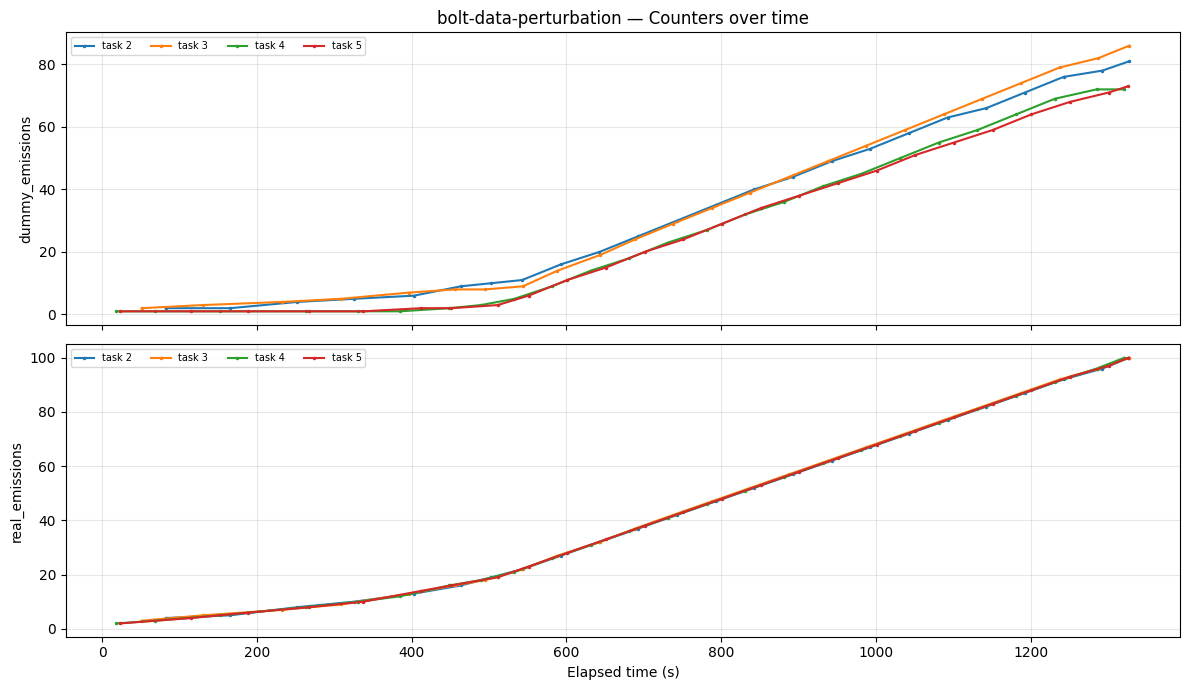

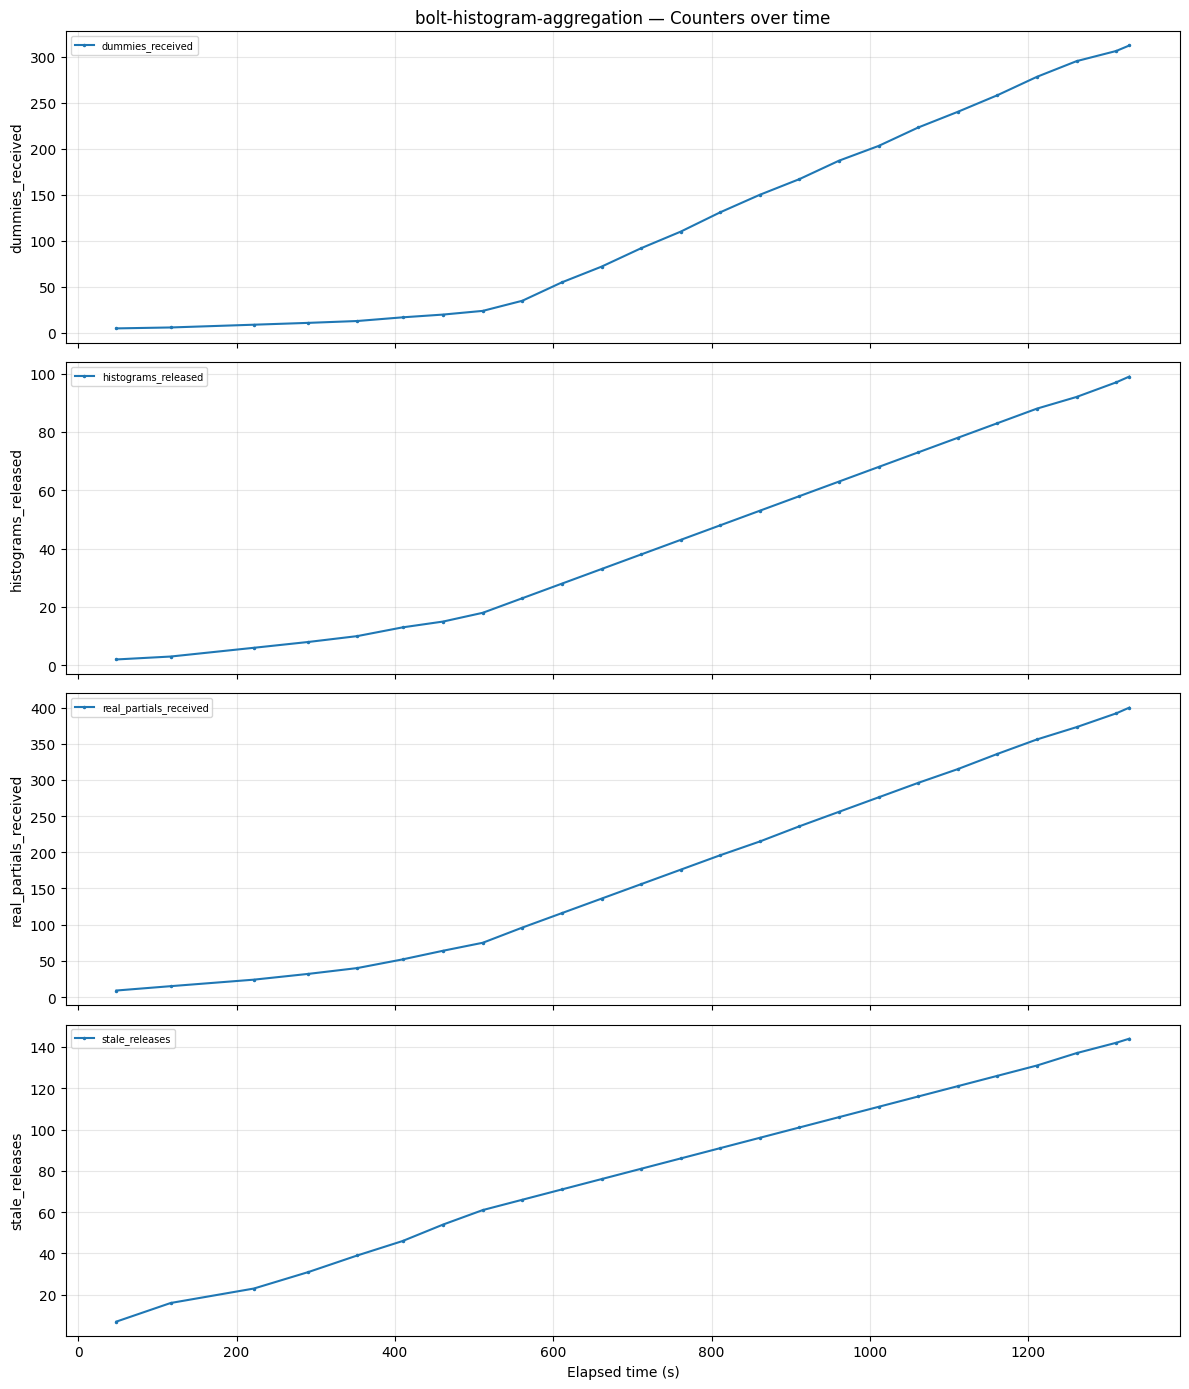

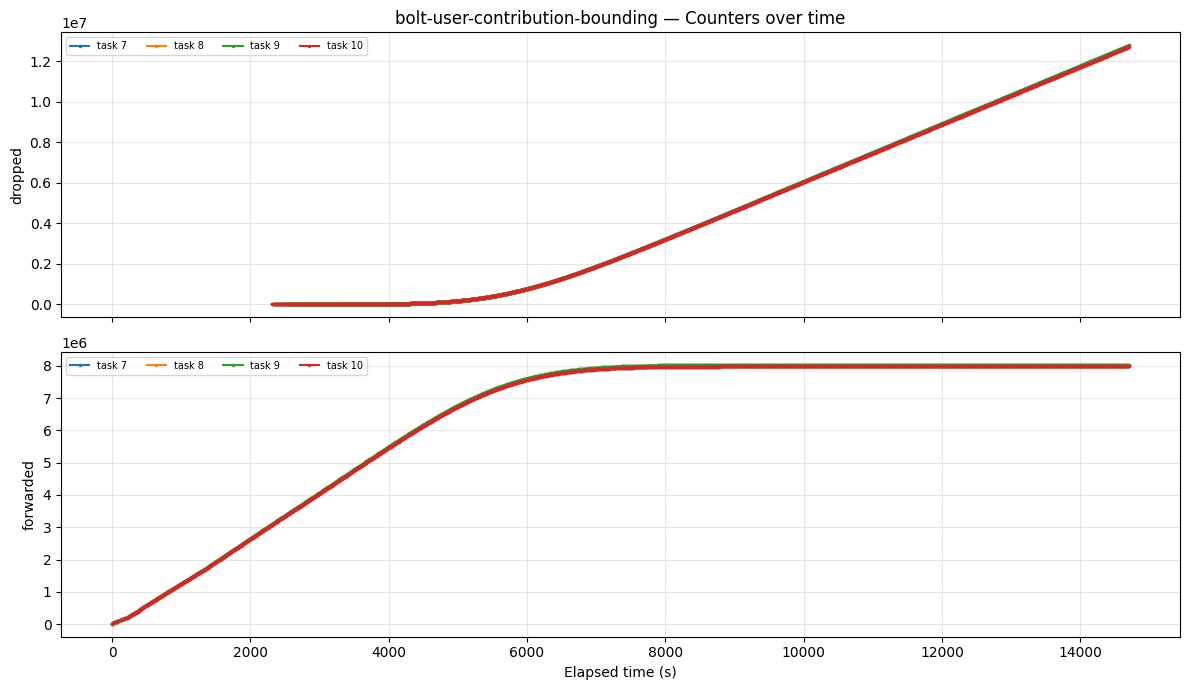

In [81]:
counters = df[df["type"] == "counter"]
if not counters.empty:
    components = _get_components(counters)

    for comp in components:
        comp_data = counters[counters["component"] == comp]
        counter_names = sorted(comp_data["name"].unique())
        if not counter_names:
            continue

        tasks = sorted(comp_data["taskId"].unique())
        n_counters = len(counter_names)
        fig, axes = plt.subplots(n_counters, 1, figsize=(12, 3.5 * n_counters), sharex=True,
                                 squeeze=False)
        for i, cn in enumerate(counter_names):
            ax = axes[i, 0]
            cd = comp_data[comp_data["name"] == cn]
            for j, task in enumerate(tasks):
                td = cd[cd["taskId"] == task].sort_values("elapsed_s")
                lbl = f"task {task}" if len(tasks) > 1 else cn
                ax.plot(td["elapsed_s"], td["total"], label=lbl,
                        color=color_for(j), linewidth=1.5, marker=".", markersize=3)
            ax.set_ylabel(cn)
            ax.legend(fontsize=7, ncol=min(len(tasks), 4))
            ax.grid(True, alpha=0.3)

        axes[0, 0].set_title(f"{comp} — Counters over time")
        format_elapsed_axis(axes[-1, 0])
        save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"counters-{comp}", PLOT_FORMAT, True)

## Plot 5: Gauge Evolution Over Time

Tracks gauge metrics (epoch_lag, ticks_to_completion, etc.) per task over time.

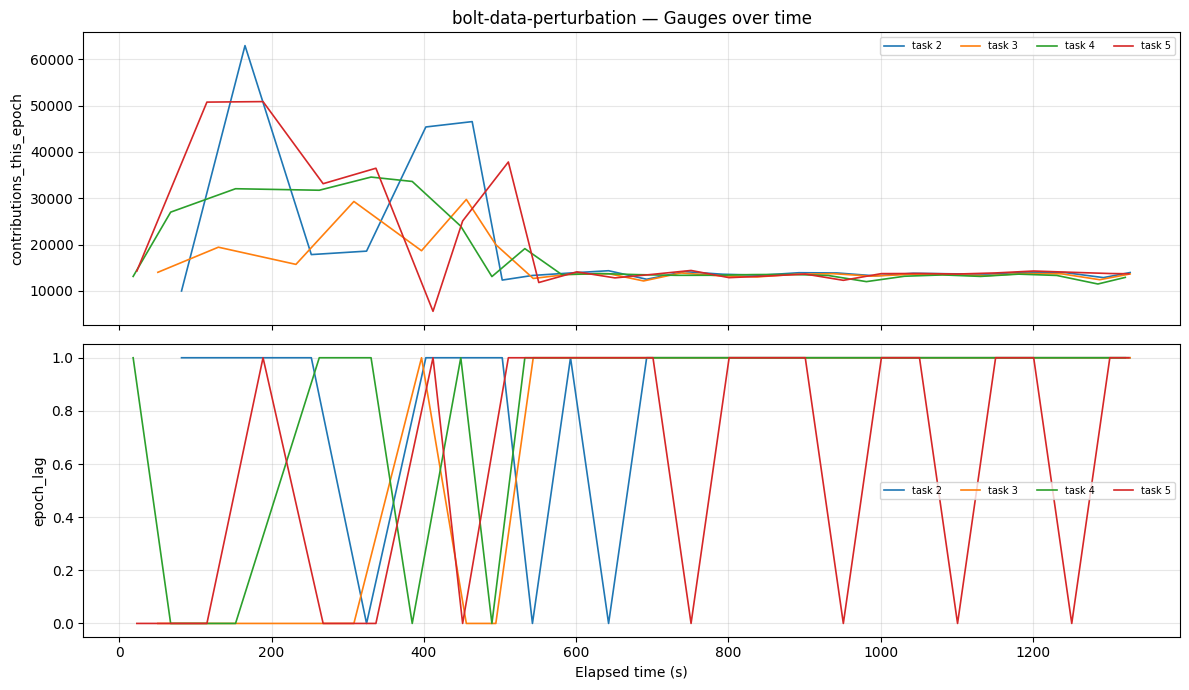

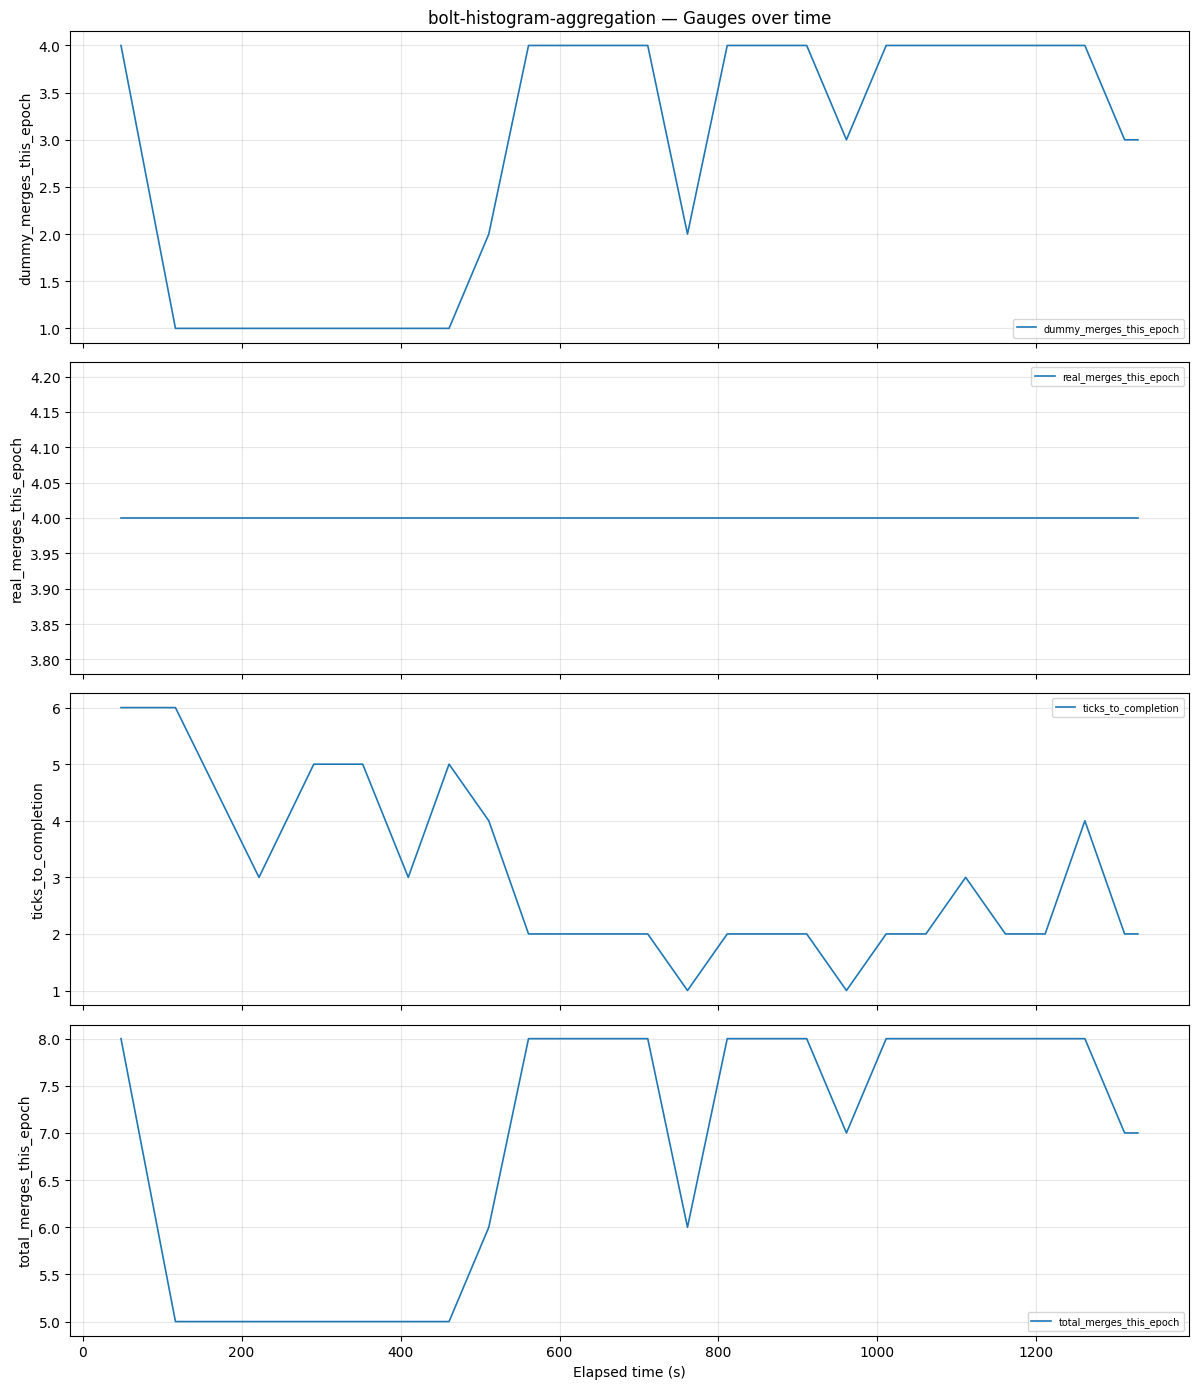

In [82]:
gauges = df[df["type"] == "gauge"]
if not gauges.empty:
    components = _get_components(gauges)

    for comp in components:
        comp_data = gauges[gauges["component"] == comp]
        gauge_names = sorted(comp_data["name"].unique())
        if not gauge_names:
            continue

        n_gauges = len(gauge_names)
        fig, axes = plt.subplots(n_gauges, 1, figsize=(12, 3.5 * n_gauges), sharex=True,
                                 squeeze=False)
        for i, gn in enumerate(gauge_names):
            ax = axes[i, 0]
            gd = comp_data[comp_data["name"] == gn]
            tasks = sorted(gd["taskId"].unique())
            for j, task in enumerate(tasks):
                td = gd[gd["taskId"] == task].sort_values("elapsed_s")
                lbl = f"task {task}" if len(tasks) > 1 else gn
                ax.plot(td["elapsed_s"], td["total"], label=lbl,
                        color=color_for(j), linewidth=1.2)
            ax.set_ylabel(gn)
            ax.legend(fontsize=7, ncol=min(len(tasks), 4))
            ax.grid(True, alpha=0.3)

        axes[0, 0].set_title(f"{comp} — Gauges over time")
        format_elapsed_axis(axes[-1, 0])
        save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"gauges-{comp}", PLOT_FORMAT, True)

## Plot 6: Task Imbalance Comparison

Side-by-side comparison of ECALL latency distribution and throughput across tasks, plus counter values per task. Only generated when multiple tasks exist.

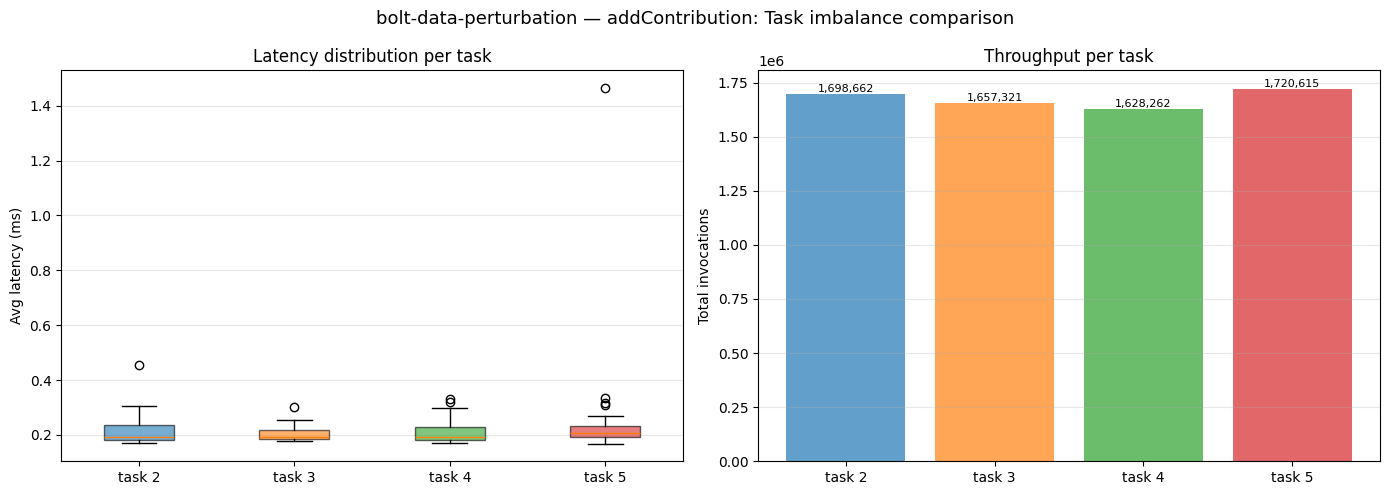

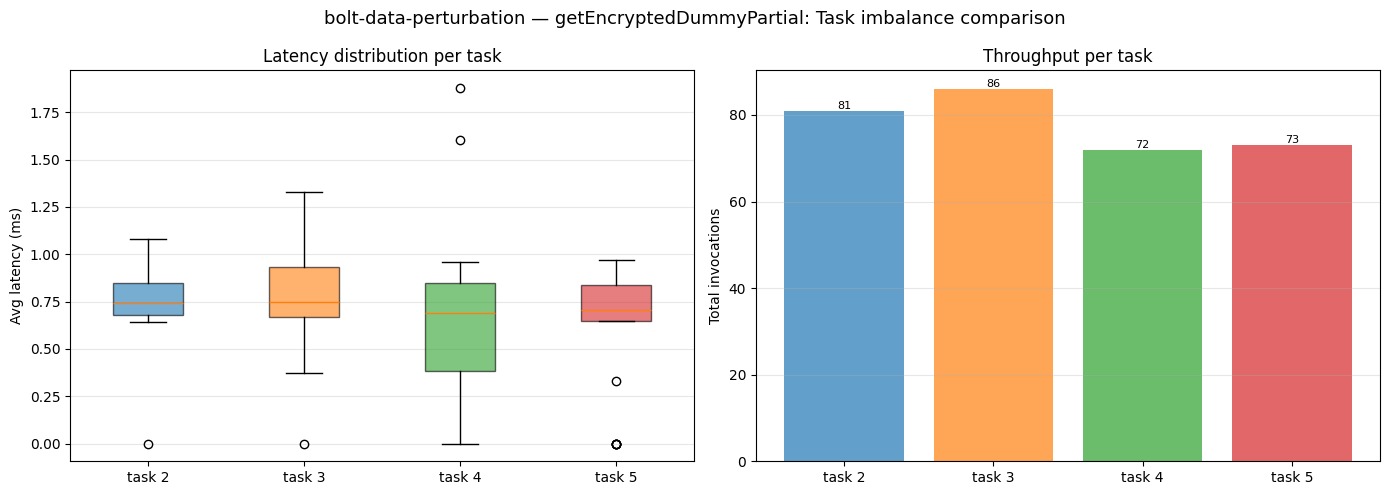

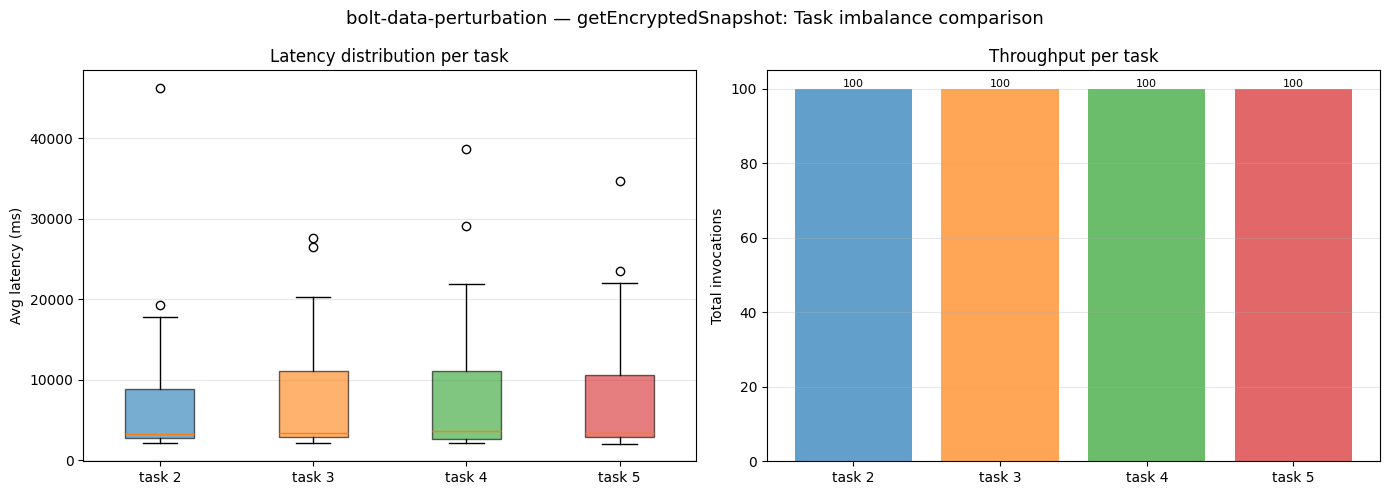

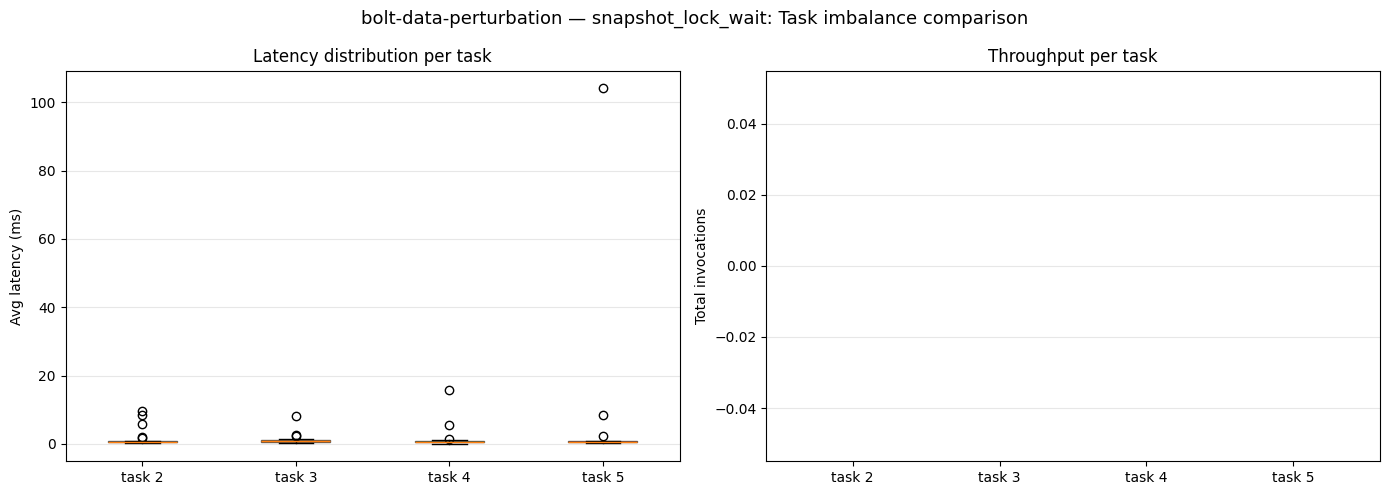

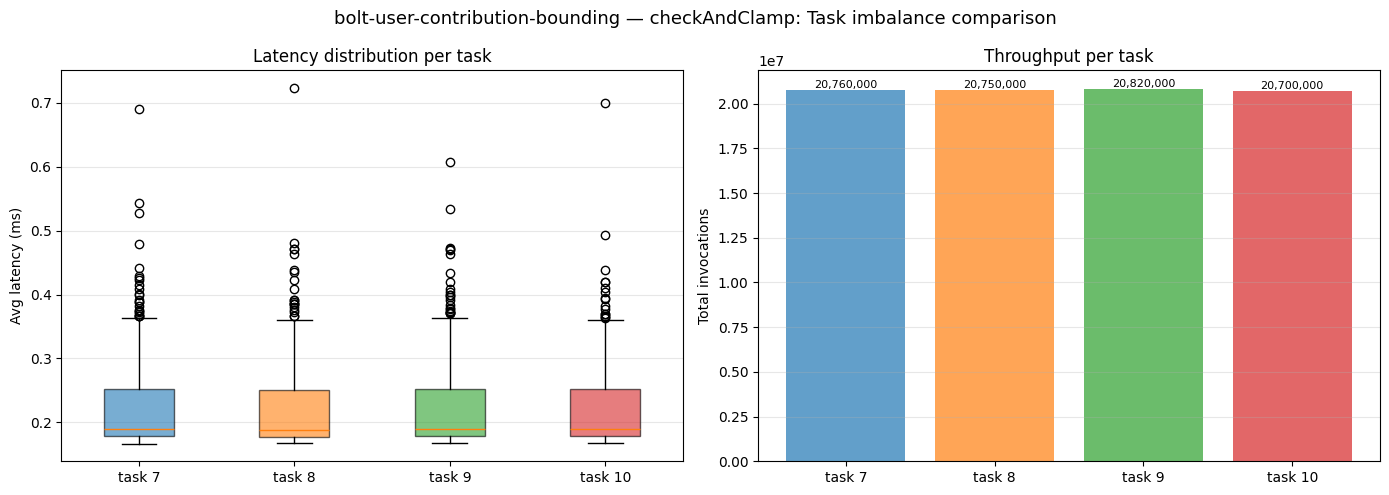

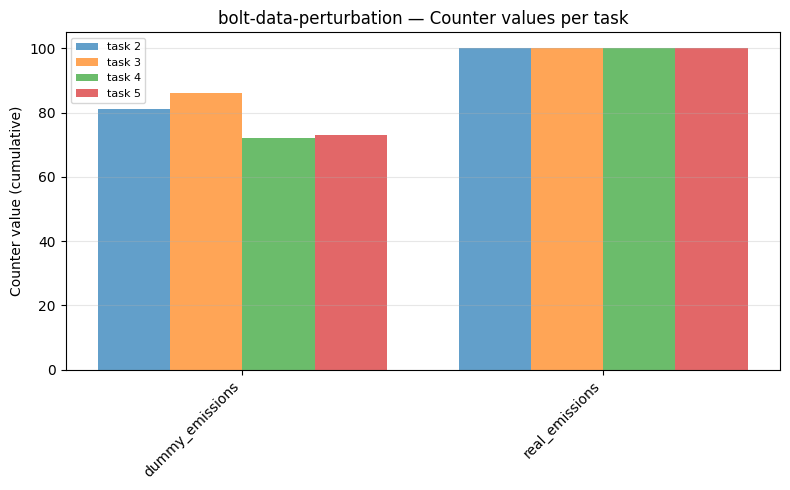

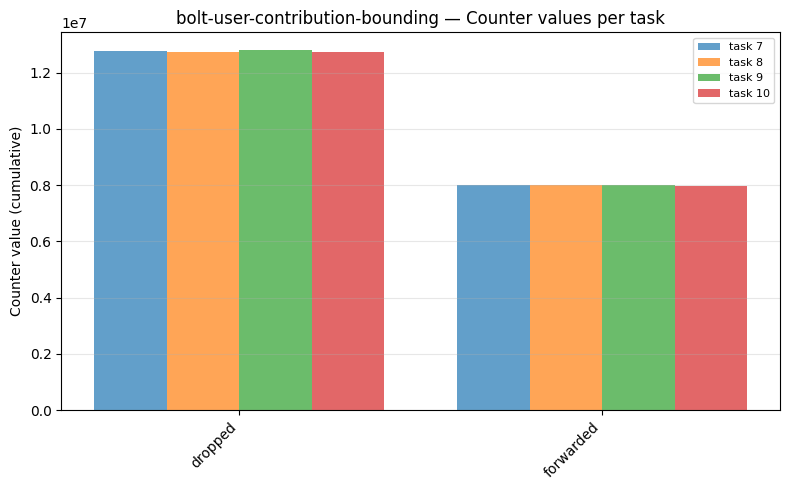

In [83]:
ecalls = df[df["type"] == "ecall"]
if not ecalls.empty:
    components = _get_components(ecalls)

    for comp in components:
        comp_data = ecalls[ecalls["component"] == comp]
        tasks = sorted(comp_data["taskId"].unique())
        if len(tasks) < 2:
            continue

        ecall_names = _get_ecall_names(ecalls, comp)

        for en in ecall_names:
            ed = comp_data[comp_data["name"] == en]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

            # Left: avg latency per task (box plot)
            task_latencies = []
            task_labels = []
            for t in tasks:
                vals = ed.loc[ed["taskId"] == t, "avgMs"].dropna()
                if not vals.empty:
                    task_latencies.append(vals.values)
                    task_labels.append(f"task {t}")

            if task_latencies:
                bp = ax1.boxplot(task_latencies, labels=task_labels, patch_artist=True)
                for i, patch in enumerate(bp["boxes"]):
                    patch.set_facecolor(color_for(i))
                    patch.set_alpha(0.6)
            ax1.set_ylabel("Avg latency (ms)")
            ax1.set_title("Latency distribution per task")
            ax1.grid(True, axis="y", alpha=0.3)

            # Right: total invocations per task (bar chart)
            task_totals = []
            for t in tasks:
                td = ed[ed["taskId"] == t]
                task_totals.append(td["total"].max() if not td.empty else 0)

            bars = ax2.bar([f"task {t}" for t in tasks], task_totals,
                           color=[color_for(i) for i in range(len(tasks))], alpha=0.7)
            ax2.set_ylabel("Total invocations")
            ax2.set_title("Throughput per task")
            ax2.grid(True, axis="y", alpha=0.3)
            for bar, val in zip(bars, task_totals):
                if val > 0:
                    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                             f"{val:,.0f}", ha="center", va="bottom", fontsize=8)

            fig.suptitle(f"{comp} — {en}: Task imbalance comparison", fontsize=13)
            save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"imbalance-{comp}-{en}", PLOT_FORMAT, True)

    # Counter imbalance (if multiple tasks)
    counters = df[df["type"] == "counter"]
    if not counters.empty:
        for comp in components:
            comp_counters = counters[counters["component"] == comp]
            tasks = sorted(comp_counters["taskId"].unique())
            if len(tasks) < 2:
                continue

            counter_names = sorted(comp_counters["name"].unique())
            if not counter_names:
                continue

            fig, ax = plt.subplots(figsize=(max(8, len(counter_names) * 2), 5))
            bar_width = 0.8 / len(tasks)
            x = np.arange(len(counter_names))

            for i, t in enumerate(tasks):
                td = comp_counters[comp_counters["taskId"] == t]
                vals = []
                for cn in counter_names:
                    v = td.loc[td["name"] == cn, "total"]
                    vals.append(v.max() if not v.empty else 0)
                ax.bar(x + i * bar_width, vals, bar_width, label=f"task {t}",
                       color=color_for(i), alpha=0.7)

            ax.set_xticks(x + bar_width * (len(tasks) - 1) / 2)
            ax.set_xticklabels(counter_names, rotation=45, ha="right")
            ax.set_ylabel("Counter value (cumulative)")
            ax.set_title(f"{comp} — Counter values per task")
            ax.legend(fontsize=8)
            ax.grid(True, axis="y", alpha=0.3)
            save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"imbalance-counters-{comp}", PLOT_FORMAT, True)

## Plot 7: Summary Dashboard

A table summarizing key metrics (avg/min/max latency, total calls, task count) across all components and ECALLs.

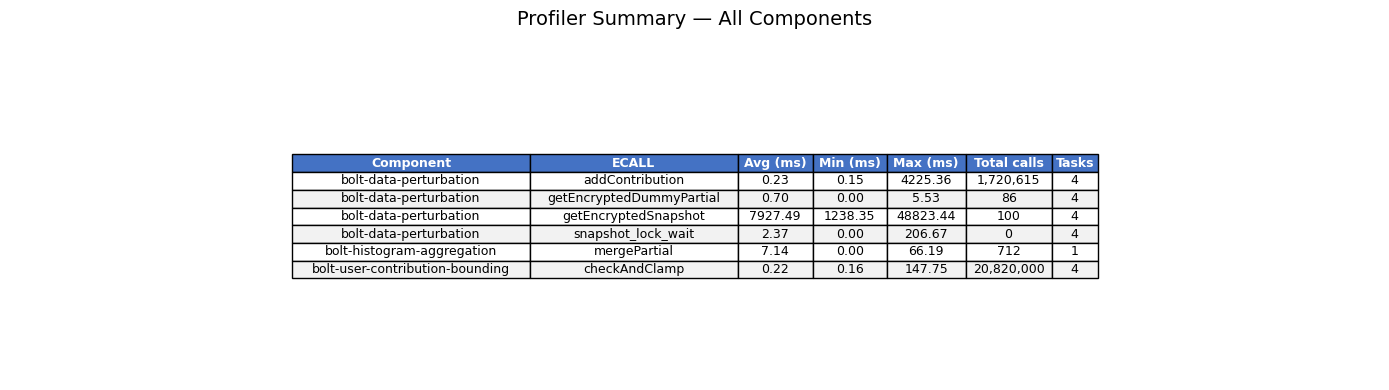

In [84]:
ecalls = df[df["type"] == "ecall"]
components = _get_components(df)

rows = []
for comp in components:
    ce = ecalls[ecalls["component"] == comp]
    for en in sorted(ce["name"].unique()):
        ed = ce[ce["name"] == en]
        rows.append({
            "Component": comp,
            "ECALL": en,
            "Avg (ms)": f"{ed['avgMs'].mean():.2f}",
            "Min (ms)": f"{ed['minMs'].min():.2f}",
            "Max (ms)": f"{ed['maxMs'].max():.2f}",
            "Total calls": f"{int(ed['total'].max()):,}",
            "Tasks": len(ed["taskId"].unique()),
        })

if rows:
    summary = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(14, max(3, 1 + 0.5 * len(rows))))
    ax.axis("off")
    table = ax.table(
        cellText=summary.values,
        colLabels=summary.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.auto_set_column_width(list(range(len(summary.columns))))
    # Style header
    for j in range(len(summary.columns)):
        table[(0, j)].set_facecolor("#4472C4")
        table[(0, j)].set_text_props(color="white", fontweight="bold")
    # Alternate row colors
    for i in range(1, len(rows) + 1):
        color = "#F2F2F2" if i % 2 == 0 else "white"
        for j in range(len(summary.columns)):
            table[(i, j)].set_facecolor(color)

    ax.set_title("Profiler Summary — All Components", fontsize=14, pad=20)
    save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, "summary-dashboard", PLOT_FORMAT, True)